# Outcome tables

The four tables the paper shows, across all eight datasets. Every dataset now
has a reference solution, so there is no supervised / unsupervised split.

Two conditions, Claude Code and Codex at the full prompt, three trials each.
Thresholds come from the verifier's `test_outputs.py`, so a limit here is the
limit the tests assert.

In [1]:
%load_ext autoreload
%autoreload 2

from IPython.display import Markdown, display
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# The house style, same as ratings_analysis.ipynb: seaborn "ticks" with the
# right and top spines dropped, and TrueType fonts so text in an exported PDF
# stays editable.
sns.set_theme(style="ticks", rc={"axes.spines.right": False,
                                "axes.spines.top": False})
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 100
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# Illustrator has no DejaVu Sans, matplotlib's default, so it substitutes a
# font with different metrics and the text in an exported PDF reflows.
# Liberation Sans is metrically identical to Arial, so a substitution costs
# nothing; Arial or Helvetica are used directly where they are installed.
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "Liberation Sans",
                                   "DejaVu Sans"]

import outcome_analysis as ot

df = ot.load()
print(f"{len(df)} trials | {df.dataset.nunique()} datasets "
      f"| arms {[ot.arm_label(a) for a in ot.ARMS]}")

48 trials | 8 datasets | arms ['Claude Code Opus 4.6', 'Codex GPT 5.4']


## 1. Summary

One cell per (dataset, agent, category): how many of the measurements the
verifier recorded were passed. A measurement it never recorded is in neither
the numerator nor the denominator, so denominators differ.

End-to-end is per trial, over Statistics and Decoder only. The checks test
whether the conversion is *defined* the way the reference defines it, and most
of what they catch is a naming or convention difference rather than a wrong
number — see §2.

In [2]:
display(Markdown(ot.summary_table(df, fmt="markdown")))

| Dataset | Agent | Checks | Statistics | Decoder | End-to-end |
|---|---|---|---|---|---|
| Allen2P | Claude 4.6 | 11/12 | 5/15 | 6/15 | 0/3 |
|  | Codex 5.4 | 9/12 | 6/15 | 3/15 | 0/3 |
| Lee2025 | Claude 4.6 | 15/15 | 14/15 | 3/3 | 2/3 |
|  | Codex 5.4 | 15/15 | 13/15 | 3/3 | 1/3 |
| Majnik2025 | Claude 4.6 | 15/15 | 9/9 | 2/3 | 2/3 |
|  | Codex 5.4 | 13/15 | 9/9 | 2/3 | 2/3 |
| Sosa2024 | Claude 4.6 | 15/15 | 15/15 | 2/18 | 0/3 |
|  | Codex 5.4 | 15/15 | 13/15 | 2/18 | 0/3 |
| Chen2024 | Claude 4.6 | 12/15 | 9/15 | 12/12 | 1/3 |
|  | Codex 5.4 | 12/15 | 12/15 | 8/12 | 0/3 |
| Hasnain2024 | Claude 4.6 | 12/15 | 8/15 | 18/18 | 0/3 |
|  | Codex 5.4 | 12/15 | 7/15 | 17/18 | 0/3 |
| Zhang2025 (IBL) | Claude 4.6 | 15/15 | 6/15 | 1/12 | 0/3 |
|  | Codex 5.4 | 15/15 | 15/15 | 12/12 | 3/3 |
| Zhong2025 | Claude 4.6 | 12/15 | 11/15 | 9/12 | 0/3 |
|  | Codex 5.4 | 12/15 | 9/15 | 10/12 | 0/3 |

In [3]:
print(ot.summary_table(df, fmt="latex"))

\begin{table}[b]
\centering
\small
\begin{NiceTabular}{l c c c c}[
  cell-space-top-limit = 1pt,
  cell-space-bottom-limit = 1pt,
  colortbl-like
]
\CodeBefore
  \rowcolors{2}{}{rowgray}
\Body
\toprule
Dataset & Checks & Statistics & Decoder & End-to-end \\
\midrule
Allen2P
& \makecell{\textcolor{highGreen}{11/12}\\\textcolor{highGreen}{9/12}}
& \makecell{5/15\\6/15}
& \makecell{6/15\\3/15}
& \makecell{0/3\\0/3}
\\
Lee2025
& \makecell{\textcolor{highGreen}{15/15}\\\textcolor{highGreen}{15/15}}
& \makecell{\textcolor{highGreen}{14/15}\\\textcolor{highGreen}{13/15}}
& \makecell{\textcolor{highGreen}{3/3}\\\textcolor{highGreen}{3/3}}
& \makecell{\textcolor{highGreen}{2/3}\\1/3}
\\
Majnik2025
& \makecell{\textcolor{highGreen}{15/15}\\\textcolor{highGreen}{13/15}}
& \makecell{\textcolor{highGreen}{9/9}\\\textcolor{highGreen}{9/9}}
& \makecell{\textcolor{highGreen}{2/3}\\\textcolor{highGreen}{2/3}}
& \makecell{\textcolor{highGreen}{2/3}\\\textcolor{highGreen}{2/3}}
\\
Sosa2024
& \makecell{\t

## 2. Checks

Pass/fail per trial. `--` where the check does not apply: Allen2P has no decoder
inputs (`dinput == 0`), and the class-count check is gated on the output
variables having been matched at all.

In [4]:
display(Markdown(ot.checks_table(df, fmt="markdown")))

| Dataset | Check | Claude 4.6 T1 | Claude 4.6 T2 | Claude 4.6 T3 | Codex 5.4 T1 | Codex 5.4 T2 | Codex 5.4 T3 |
|---|---|---|---|---|---|---|---|
| Allen2P | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | -- | -- | -- | -- | -- | -- |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | N output classes | ✗ | ✓ | ✓ | ✗ | ✗ | ✗ |
| Lee2025 | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | N output classes | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Majnik2025 | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✗ | ✓ |
|  | N output classes | ✓ | ✓ | ✓ | ✓ | ✗ | ✓ |
| Sosa2024 | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | N output classes | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Chen2024 | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | N output classes | ✗ | ✗ | ✗ | ✗ | ✗ | ✗ |
| Hasnain2024 | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | N output classes | ✗ | ✗ | ✗ | ✗ | ✗ | ✗ |
| Zhang2025 (IBL) | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | N output classes | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Zhong2025 | Required files | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Data format | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Input match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | Output match | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
|  | N output classes | ✗ | ✗ | ✗ | ✗ | ✗ | ✗ |

In [5]:
print(ot.checks_table(df, fmt="latex"))

% requires \usepackage{booktabs, multirow, xcolor, amssymb}
\newcommand{\markbox}[1]{\makebox[1.15em][c]{#1}}
\newcommand{\ckpass}{\markbox{\textcolor{green!55!black}{\checkmark}}}
\newcommand{\ckfail}{\markbox{\textcolor{red!70!black}{$\times$}}}
\newcommand{\ckna}{\markbox{--}}

\begin{table}[htb]
\centering
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.25}
\begin{tabular}{l l ccccc}
\toprule
Dataset & Agent & Files & Format & Inputs & Outputs & N classes \\
\midrule
\multirow{2}{*}{Allen2P} & Claude 4.6 & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckna\ckna\ckna & \ckpass\ckpass\ckpass & \ckfail\ckpass\ckpass \\
 & Codex 5.4 & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckna\ckna\ckna & \ckpass\ckpass\ckpass & \ckfail\ckfail\ckfail \\
\midrule
\multirow{2}{*}{Lee2025} & Claude 4.6 & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass$^{*}$ & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass \\
 & Codex 5.4 & \ckpass\ckpass\ckpass & \ckpass\ckpas

## 3. Dataset statistics

Agent / reference ratio, passing inside [0.9, 1.1]. Majnik2025's starred rows
are excluded from its Statistics count — that experiment has no trial structure,
so every agent chose its own binning.

In [6]:
display(Markdown(ot.scale_table(df, fmt="markdown")))

| Dataset | Metric | Claude 4.6 T1 | Claude 4.6 T2 | Claude 4.6 T3 | Codex 5.4 T1 | Codex 5.4 T2 | Codex 5.4 T3 | Reference |
|---|---|---|---|---|---|---|---|---|
| Allen2P | Sessions | 0.856 | 0.856 | 0.856 | 1.191 | 0.843 | 0.843 | 236 |
|  | Trials | 0.730 | 0.730 | 0.730 | 1.183 | 0.717 | 0.717 | 71,242 |
|  | Subjects | 1.027 | 1.027 | 1.027 | 1.027 | 1.027 | 1.027 | 37 |
|  | Neurons | 0.711 | 0.711 | 0.711 | 1.012 | 0.705 | 0.705 | 41,390 |
|  | T median | 0.990 | 0.044 | 0.964 | 0.325 | 0.966 | 0.964 | 265.2 |
| Lee2025 | Sessions | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 207 |
|  | Trials | 1.011 | 1.000 | 1.000 | 1.011 | 0.990 | 1.000 | 8,187 |
|  | Subjects | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 7 |
|  | Neurons | 1.000 | 1.000 | 1.000 | 1.000 | 0.987 | 1.000 | 69,744 |
|  | T median | 1.000 | 0.333 | 1.000 | 0.333 | 0.171 | 1.000 | 1800.0 |
| Majnik2025 | Sessions | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 41 |
|  | Trials* | 0.500 | 0.500 | 0.500 | 0.500 | 0.500 | 0.500 | 1,090 |
|  | Subjects | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 6 |
|  | Neurons | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 20,445 |
|  | T median* | 2.000 | 2.000 | 2.000 | 2.000 | 2.000 | 2.000 | 180.0 |
| Sosa2024 | Sessions | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 152 |
|  | Trials | 1.000 | 1.000 | 1.000 | 0.994 | 0.994 | 0.994 | 12,216 |
|  | Subjects | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 11 |
|  | Neurons | 1.001 | 1.002 | 1.000 | 1.003 | 0.857 | 1.003 | 138K |
|  | T median | 1.000 | 1.000 | 1.000 | 0.994 | 0.868 | 0.994 | 197.5 |
| Chen2024 | Sessions | 0.832 | 1.000 | 0.832 | 1.000 | 1.000 | 1.000 | 173 |
|  | Trials | 0.823 | 0.986 | 0.824 | 0.565 | 0.813 | 0.813 | 90,860 |
|  | Subjects | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 28 |
|  | Neurons | 0.819 | 1.000 | 0.834 | 1.000 | 1.000 | 1.000 | 69,453 |
|  | T median | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 80.0 |
| Hasnain2024 | Sessions | 1.000 | 1.000 | 1.000 | 1.000 | 0.273 | 1.000 | 44 |
|  | Trials | 0.871 | 1.004 | 1.000 | 0.869 | 0.175 | 0.869 | 13,762 |
|  | Subjects | 1.000 | 1.000 | 1.000 | 1.000 | 0.500 | 1.000 | 14 |
|  | Neurons | 1.257 | 1.257 | 1.257 | 1.256 | 0.266 | 1.256 | 1,954 |
|  | T median | 0.500 | 0.500 | 0.500 | 1.000 | 1.000 | 1.000 | 1000.0 |
| Zhang2025 (IBL) | Sessions | 0.889 | 0.760 | 0.993 | 0.993 | 0.993 | 0.993 | 441 |
|  | Trials | 0.887 | 0.778 | 0.987 | 0.987 | 0.987 | 0.987 | 188,740 |
|  | Subjects | 0.956 | 0.874 | 1.000 | 1.000 | 1.000 | 1.000 | 135 |
|  | Neurons | 7.387 | 6.677 | 8.224 | 1.005 | 1.005 | 1.005 | 72,417 |
|  | T median | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 100.0 |
| Zhong2025 | Sessions | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 89 |
|  | Trials | 1.010 | 1.010 | 1.010 | 0.951 | 1.010 | 1.010 | 37,728 |
|  | Subjects | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 19 |
|  | Neurons | 1.143 | 1.000 | 1.143 | 0.074 | 0.087 | 0.025 | 4,105K |
|  | T median | 1.039 | 1.579 | 1.569 | 0.722 | 0.732 | 0.729 | 31.0 |

In [7]:
print(ot.scale_table(df, fmt="latex"))

\begin{table}[!ht]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code Opus 4.6} & \multicolumn{3}{c}{Codex GPT 5.4} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Metric & T1 & T2 & T3 & T1 & T2 & T3 &  \\
\midrule
\multirow{5}{*}{Allen2P} & Sessions & \textcolor{orange}{0.856} & \textcolor{orange}{0.856} & \textcolor{orange}{0.856} & \textcolor{blue}{1.191} & \textcolor{orange}{0.843} & \textcolor{orange}{0.843} & 236 \\
 & Trials & \textcolor{orange}{0.730} & \textcolor{orange}{0.730} & \textcolor{orange}{0.730} & \textcolor{blue}{1.183} & \textcolor{orange}{0.717} & \textcolor{orange}{0.717} & 71,242 \\
 & Subjects & 1.027 & 1.027 & 1.027 & 1.027 & 1.027 & 1.027 & 37 \\
 & Neurons & \textcolor{orange}{0.711} & \textcolor{orange}{0.711} & \textcolor{orange}{0.711} & 1.012 & \textcolor{orange}{0.705} & \textcolor{orange}{0.705} & 41,390 \\
 & T median & 0.990 & \textcolor{red}{0.044} & 0.964 & \textcolor{r

## 4. Decoder

Agent / reference validation balanced accuracy, passing at ≥ 0.90 — the same boundary below which a cell is colored. Rows are the
reference's output variables; chance is `1 / n_classes` from the reference.

Four Zhong2025/Codex cells are recomputed. The verifier pairs agent to reference
variables by a joint assignment dominated by name similarity, and in trials 2
and 3 it swapped `position` with `visual_stimulus` — the agent's 15-class
`visual_stimulus_category` went to the reference's 5-class `position` at an
assignment cost of 1.65, against at most 0.42 for every other pairing in the
corpus. `repaired_ratio` re-derives those from the per-variable accuracies,
pairing by name; the same recomputation reproduces the recorded ratio exactly
for all 188 other cells.

In [8]:
display(Markdown(ot.decoder_table(df, fmt="markdown")))

| Dataset | Variable | Claude 4.6 T1 | Claude 4.6 T2 | Claude 4.6 T3 | Codex 5.4 T1 | Codex 5.4 T2 | Codex 5.4 T3 | Reference (chance) |
|---|---|---|---|---|---|---|---|---|
| Allen2P | trial_outcome | 0.908 | 0.979 | 0.829 | 0.894 | 0.826 | 0.830 | 0.323 (0.250) |
|  | running_speed | 0.819 | 1.228 | 0.702 | 0.773 | 0.698 | 0.697 | 0.350 (0.200) |
|  | pupil_diameter | 0.658 | 1.099 | 0.627 | 0.732 | 0.628 | 0.627 | 0.433 (0.200) |
|  | image_name | 0.974 | 1.145 | 0.371 | 0.634 | 0.482 | 0.482 | 0.395 (0.062) |
|  | image_change | 1.089 | 1.157 | 0.905 | 1.029 | 1.001 | 1.003 | 0.587 (0.500) |
| Lee2025 | position | 1.007 | 1.108 | 1.006 | 1.029 | 1.252 | 1.002 | 0.548 (0.111) |
| Majnik2025 | motion_energy | 1.545 | 1.293 | 0.938 | 1.525 | ✗ | 1.529 | 0.303 (0.200) |
| Sosa2024 | position | 0.723 | 0.762 | 0.801 | 0.772 | 0.792 | 0.750 | 0.661 (0.200) |
|  | speed | 0.719 | 0.743 | 0.754 | 0.741 | 0.834 | 0.767 | 0.559 (0.200) |
|  | lick | 0.868 | 0.806 | 0.849 | 0.788 | 0.847 | 0.863 | 0.742 (0.500) |
|  | distance_to_reward | 0.608 | 0.630 | 0.754 | 0.760 | 0.742 | 0.736 | 0.562 (0.143) |
|  | reward_location | 0.946 | 0.962 | 0.958 | 0.967 | 0.978 | 0.969 | 0.841 (0.333) |
|  | reward_outcome | 0.905 | 0.907 | 0.902 | 0.918 | 0.953 | 0.901 | 0.575 (0.500) |
| Chen2024 | choice | 1.066 | 1.049 | 1.068 | 0.901 | 1.100 | 1.104 | 0.674 (0.333) |
|  | outcome | 1.000 | 1.011 | 1.000 | 0.812 | 1.134 | 1.188 | 0.655 (0.333) |
|  | early_lick | 1.005 | 1.025 | 1.009 | 0.925 | 1.016 | 1.023 | 0.743 (0.500) |
|  | tongue_y | 1.232 | 1.146 | 1.048 | 0.705 | 1.185 | 1.192 | 0.645 (0.250) |
| Hasnain2024 | context | 1.058 | 1.031 | 1.007 | 1.018 | 0.902 | 1.017 | 0.829 (0.500) |
|  | outcome | 1.074 | 1.141 | 1.135 | 1.083 | 1.020 | 1.067 | 0.612 (0.333) |
|  | lick_direction | 1.105 | 1.068 | 1.043 | 1.042 | 0.976 | 1.036 | 0.621 (0.333) |
|  | tongue_velocity | 1.415 | 1.434 | 1.361 | 1.395 | 1.348 | 1.584 | 0.572 (0.333) |
|  | paw_velocity | 1.043 | 1.077 | 1.045 | 1.088 | 1.063 | 1.062 | 0.541 (0.333) |
|  | motion_energy | 1.067 | 1.133 | 1.063 | 1.035 | 1.051 | 1.036 | 0.719 (0.333) |
| Zhang2025 (IBL) | prior | 0.903 | 0.892 | 0.876 | 1.001 | 0.995 | 1.007 | 0.666 (0.333) |
|  | choice | 0.911 | 0.916 | 0.935 | 1.013 | 1.010 | 1.011 | 0.614 (0.500) |
|  | wheel_speed | 0.984 | 0.972 | 0.965 | 1.045 | 1.060 | 1.061 | 0.606 (0.333) |
|  | whisker_motion_energy | 0.978 | 0.967 | 0.963 | 1.266 | 1.269 | 1.270 | 0.585 (0.333) |
| Zhong2025 | licking | 1.025 | 0.998 | 1.030 | 0.967 | 0.956 | 0.990 | 0.850 (0.500) |
|  | position | 0.897 | 0.948 | 1.029 | 1.049 | 0.926 | 2.073 | 0.310 (0.250) |
|  | running_speed | 1.111 | 1.118 | 1.146 | 0.772 | 0.804 | 1.218 | 0.362 (0.250) |
|  | visual_stimulus | 0.715 | 0.591 | 0.641 | 0.613 | 0.682 | 1.205 | 0.664 (0.250) |

In [9]:
print(ot.decoder_table(df, fmt="latex"))

\begin{table}[!ht]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code Opus 4.6} & \multicolumn{3}{c}{Codex GPT 5.4} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 & (Chance) \\
\midrule
\multirow{5}{*}{Allen2P} & trial\_outcome & \textcolor{red}{0.908} & 0.979 & \textcolor{red}{0.829} & \textcolor{red}{0.894} & \textcolor{red}{0.826} & \textcolor{red}{0.830} & 0.323 (0.250) \\
 & running\_speed & \textcolor{red}{0.819} & \textcolor{blue}{1.228} & \textcolor{red}{0.702} & \textcolor{red}{0.773} & \textcolor{red}{0.698} & \textcolor{red}{0.697} & 0.350 (0.200) \\
 & pupil\_diameter & \textcolor{red}{0.658} & \textcolor{blue}{1.099} & \textcolor{red}{0.627} & \textcolor{red}{0.732} & \textcolor{red}{0.628} & \textcolor{red}{0.627} & 0.433 (0.200) \\
 & image\_name & \textcolor{red}{0.974} & \textcolor{blue}{1.145} & \textcolor{red}{0.371} & \textcolor{red}{0.634} & \textc

## 5. The harness

All four conditions ran the full prompt, so each pair holds the underlying model
fixed and varies only the scaffold. A point is one trial's share of verifier
metrics passed — Statistics and Decoder pooled, at the same thresholds the
tables above use, so it is the summary cell broken out by trial. The checks are
left out for the reason End-to-end leaves them out.

A share, not a mean of the ratios: those are two-sided and unbounded above, so
Zhang2025's 7–8× neuron count would average as better than a perfect 1.0.
`lesion_analysis` scores its nine categories the same way.

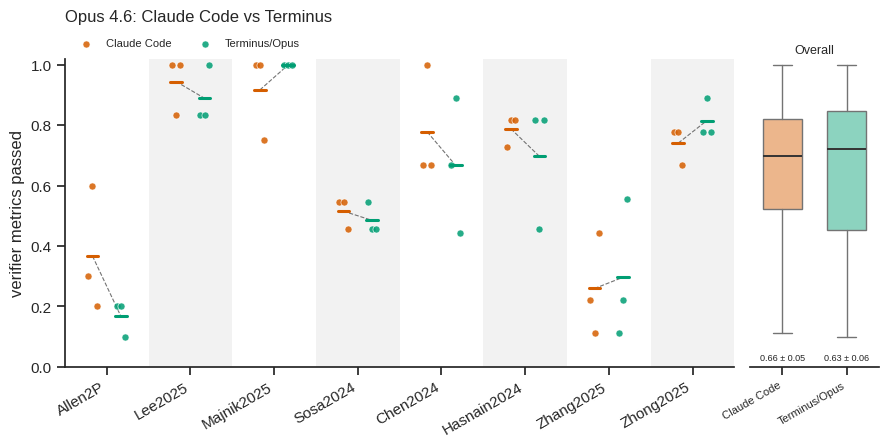

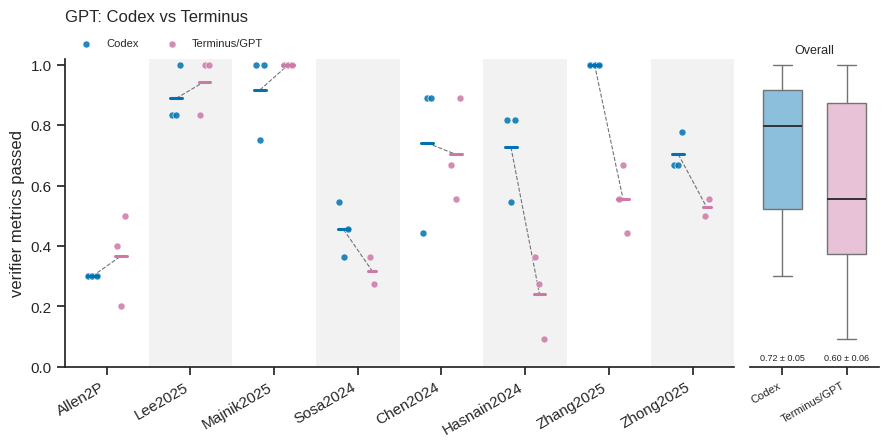

In [10]:
df_all = ot.load(arms=ot.ALL_ARMS)      # all six conditions, not just the paper's two
scores = ot.trial_scores(df_all)

for title, pair in ot.HARNESS_PAIRS:
    fig, _ = ot.condition_scatter(scores, pair, title=title)
    plt.show()

## 6. The prompt

Claude Code and Codex are the only agents that ran both prompts.

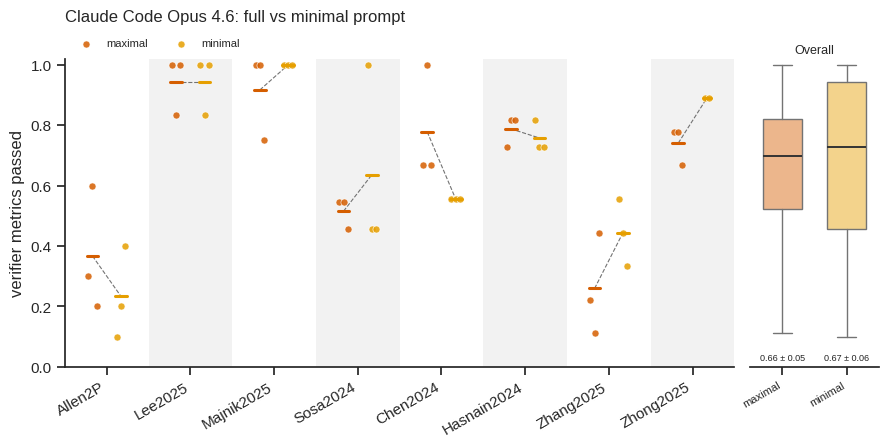

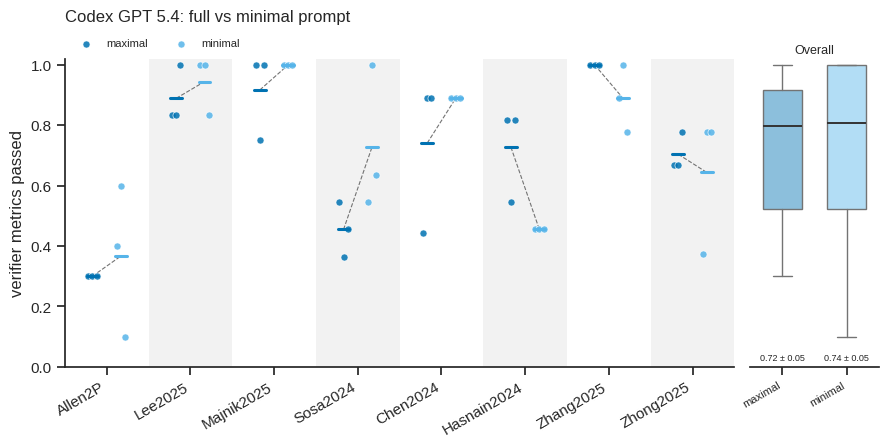

In [11]:
for title, pair in ot.PROMPT_PAIRS:
    fig, _ = ot.condition_scatter(scores, pair, title=title)
    plt.show()